# Soccer Analytics with Machine Learning — Live Course Notebook

**O'Reilly Live Course | July 6, 2026**

Welcome\! This notebook is your hands-on companion for today's live course. We'll analyze a single World Cup match from start to finish, building progressively more sophisticated models along the way.

**Our match:** 2019 FIFA Women's World Cup Quarter-Final

**What we'll build today:**
1. Load and explore professional event data
2. Create soccer-specific visualizations (shot maps, passing networks)
3. Build an Expected Goals (xG) model using logistic regression
4. Predict goal counts with Poisson regression
5. See how a neural network approaches the same problem

**Companion book:** *Soccer Analytics with Machine Learning* (O'Reilly, 2026)  
**GitHub repo:** [SoccerAnalyticsML](https://github.com/SoccerAnalyticsML/Soccer-Analytics-with-Machine-Learning)

---

## Part 0: Setup & Imports

Run the cell below to load all required libraries. If any import fails, check that you've installed the dependencies:

```bash
pip install -r requirements_live_course.txt
```

In [1]:
# === Core Libraries ===
import json
import numpy as np
import pandas as pd
from pathlib import Path

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

# === Machine Learning ===
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import statsmodels.api as sm

# === Style ===
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All imports successful! You are ready to go.")

All imports successful! You are ready to go.


In [5]:
# === Data Path ===
# The course data is pre-downloaded in the 'data' folder.
# No internet connection needed during the exercises.
DATA_DIR = Path("data")

# Verify data files exist
assert (DATA_DIR / "matches_72_30.json").exists(), "Match data not found! Check the data/ folder."
print(f"Data directory: {DATA_DIR.resolve()}")
print("Data files found. Ready to begin!")

Data directory: /Users/arijoury/Documents/Garden/OReilly/soccer_live_course/materials/data
Data files found. Ready to begin!


---
## Part 1: Loading the Match (Exercise 1)

StatsBomb event data records every on-ball action in a match: every pass, shot, tackle,
dribble, and foul — along with who did it, where on the pitch, and when.

Think of it like a detailed medical record — every event in a patient's journey,
timestamped and categorized. Here, the "patient" is the match.

**Book reference:** Chapter 3 — *Exploratory Data Analysis in Soccer*

In [6]:
# Load the WWC 2019 match listing
matches = json.load(open(DATA_DIR / "matches_72_30.json", "r"))
matches_df = pd.json_normalize(matches)

print(f"The 2019 Women's World Cup had {len(matches_df)} matches in the StatsBomb dataset.")
print(f"\nColumns available: {len(matches_df.columns)}")

The 2019 Women's World Cup had 52 matches in the StatsBomb dataset.

Columns available: 42


In [7]:
# Let's find our match — display the knockout stage matches
key_cols = [c for c in ["match_id", "match_date",
            "home_team.home_team_name", "away_team.away_team_name",
            "home_score", "away_score", "competition_stage.name"]
            if c in matches_df.columns]

knockouts = matches_df[matches_df["competition_stage.name"].isin(
    ["Quarter-finals", "Semi-finals", "Final", "Round of 16"]
)]

print("Knockout stage matches:")
knockouts[key_cols].sort_values("match_date")

Knockout stage matches:


,match_id,match_date,home_team.home_team_name,away_team.away_team_name,home_score,away_score,competition_stage.name
5,68357,2019-06-22,Norway Women's,Australia Women's,1,1,Round of 16
17,68355,2019-06-22,Germany Women's,Nigeria Women's,3,0,Round of 16
19,69137,2019-06-23,France Women's,Brazil Women's,2,1,Round of 16
44,68362,2019-06-23,England Women's,Cameroon Women's,3,0,Round of 16
15,69163,2019-06-24,Sweden Women's,Canada Women's,1,0,Round of 16
51,69161,2019-06-24,Spain Women's,United States Women's,1,2,Round of 16
45,69191,2019-06-25,Italy Women's,China PR Women's,2,0,Round of 16
46,69188,2019-06-25,Netherlands Women's,Japan Women's,2,1,Round of 16
48,69258,2019-07-02,England Women's,United States Women's,1,2,Semi-finals
49,69284,2019-07-03,Netherlands Women's,Sweden Women's,1,0,Semi-finals


### ✏️ Exercise 1: Load the match events

**Task:** Load the event data for our chosen match and explore its structure.

**Steps:**
1. Find the `match_id` for our match from the table above
2. Load the events JSON file using the pattern `events_{match_id}.json`
3. Convert to a DataFrame using `pd.json_normalize`

**Output:** Paste the two team names and the total number of events into the chat.

**Time:** 8 minutes

In [10]:
# === YOUR CODE HERE ===

# Step 1: Identify the match_id (look at the table above)
MATCH_ID = ____  # Replace with the correct match_id

# Step 2: Load the events JSON file
events_raw = json.load(open(DATA_DIR / f"events_{MATCH_ID}.json", "r"))

# Step 3: Convert to DataFrame
events_df = pd.json_normalize(events_raw, sep="_")
events_df["match_id"] = MATCH_ID

# Explore
print(f"Loaded {len(events_df)} events from match {MATCH_ID}")
print(f"\nTeams: {events_df['team_name'].unique()}")
print(f"\nEvent types:\n{events_df['type_name'].value_counts().head(10)}")

Loaded 3161 events from match 69202

Teams: ["France Women's" "United States Women's"]

Event types:
type_name
Pass             843
Ball Receipt*    806
Carry            654
Pressure         314
Ball Recovery    113
Duel              78
Block             43
Clearance         41
Miscontrol        35
Goal Keeper       33
Name: count, dtype: int64


In [11]:
# ▶️ CATCH-UP CELL — run this if you got stuck or fell behind.
# It finds our match (USA vs France) automatically and loads the events,
# so you can keep up with the rest of the notebook no matter what.
home = matches_df["home_team.home_team_name"]
away = matches_df["away_team.away_team_name"]
mask = ((home.str.contains("United States", case=False, na=False) |
         away.str.contains("United States", case=False, na=False)) &
        (home.str.contains("France", case=False, na=False) |
         away.str.contains("France", case=False, na=False)))
MATCH_ID = int(matches_df.loc[mask, "match_id"].iloc[0])

events_raw = json.load(open(DATA_DIR / f"events_{MATCH_ID}.json", "r"))
events_df = pd.json_normalize(events_raw, sep="_")
events_df["match_id"] = MATCH_ID
print(f"✅ Caught up: loaded {len(events_df)} events from match {MATCH_ID}.")
print(f"Teams: {events_df['team_name'].unique()}")


✅ Caught up: loaded 3161 events from match 69202.
Teams: ["France Women's" "United States Women's"]


<details>
<summary>💡 Click for solution</summary>

Look at the knockout table above to find the match_id for the quarter-final.
Replace `____` with that number, e.g. `MATCH_ID = 22886`.

</details>

---
## Part 2: Shot Map Visualization (Exercise 2)

Now let's create our first soccer-specific visualization: a **shot map**.

We'll use `mplsoccer`, a Python library designed for soccer data visualization.
It handles the pitch drawing and coordinate system for us.

**Book reference:** Chapter 3 — *Soccer-Specific Visualizations with mplsoccer*

In [12]:
# Extract all shots from the match
shots = events_df[events_df["type_name"] == "Shot"].copy()

# Extract x, y coordinates
if "location" in shots.columns:
    shots[["x", "y"]] = shots["location"].apply(pd.Series)
elif "location_0" in shots.columns:
    shots["x"] = shots["location_0"]
    shots["y"] = shots["location_1"]

# Create binary goal indicator
shots["is_goal"] = (shots["shot_outcome_name"] == "Goal").astype(int)

print(f"Total shots in the match: {len(shots)}")
print(f"\nShots per team:")
print(shots.groupby("team_name")["is_goal"].agg(["count", "sum"]).rename(
    columns={"count": "shots", "sum": "goals"}
))

Total shots in the match: 30

Shots per team:
                       shots  goals
team_name                          
France Women's            20      1
United States Women's     10      2


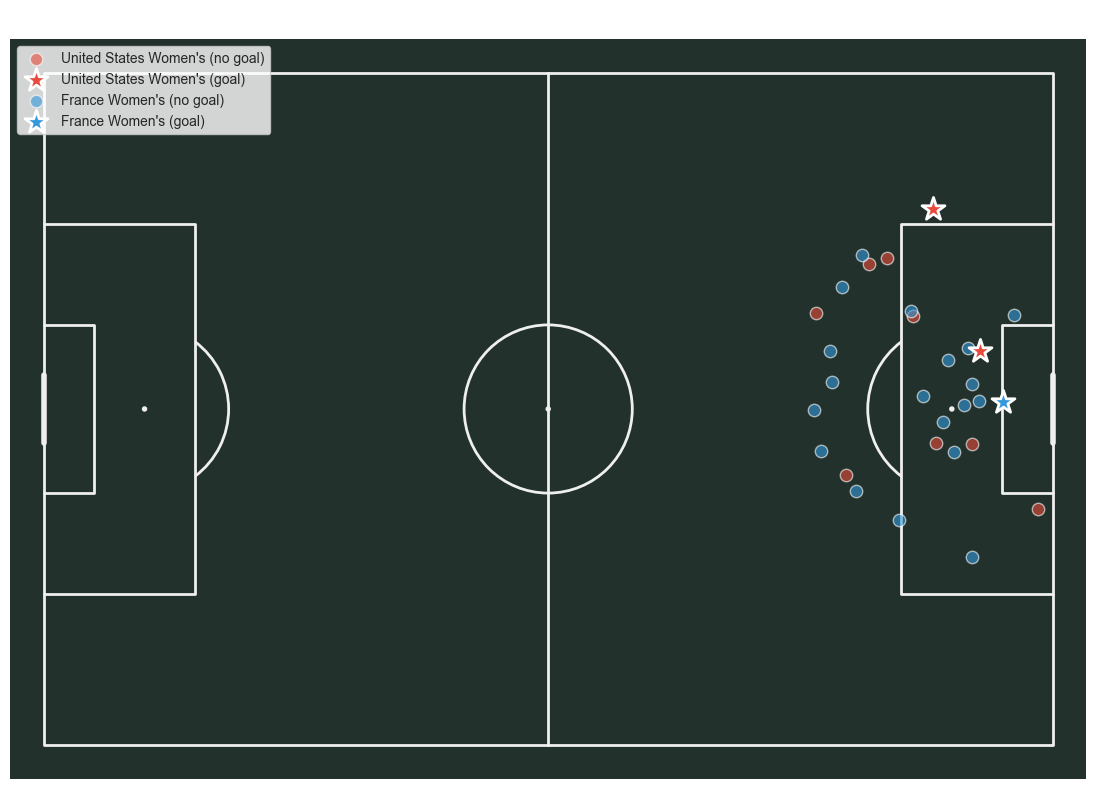

In [13]:
# === Instructor Demo: Shot Map ===
pitch = Pitch(pitch_color="#22312b", line_color="#efefef", linewidth=2)
fig, ax = pitch.draw(figsize=(12, 8))

teams = shots["team_name"].unique()
colors = ["#e74c3c", "#3498db"]  # Red for team 1, blue for team 2

for team, color in zip(teams, colors):
    team_shots = shots[shots["team_name"] == team]

    # Non-goals: smaller, transparent
    non_goals = team_shots[team_shots["is_goal"] == 0]
    pitch.scatter(non_goals["x"], non_goals["y"], ax=ax,
                  s=80, color=color, edgecolors="white",
                  linewidth=1, alpha=0.6, label=f"{team} (no goal)")

    # Goals: larger, star marker
    goals = team_shots[team_shots["is_goal"] == 1]
    pitch.scatter(goals["x"], goals["y"], ax=ax,
                  s=300, color=color, edgecolors="white",
                  linewidth=2, marker="*", zorder=5, label=f"{team} (goal)")

ax.legend(loc="upper left", fontsize=10, framealpha=0.8)
ax.set_title(f"Shot Map: {teams[0]} vs {teams[1]}", fontsize=16, color="white", pad=10)
plt.tight_layout()
plt.show()

### ✏️ Exercise 2: Create your own shot map

**Task:** Recreate the shot map above. Customize it if you like — try different
colors, marker sizes, or add player name annotations\!

**Output:** Paste the total shot count per team into the chat.

**Time:** 7 minutes

In [ ]:
# === YOUR CODE HERE ===
pitch = Pitch(pitch_color="#22312b", line_color="#efefef", linewidth=2)
fig, ax = pitch.draw(figsize=(12, 8))

# Your shot plotting code here...



plt.tight_layout()
plt.savefig("my_shot_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Shot map saved as my_shot_map.png")

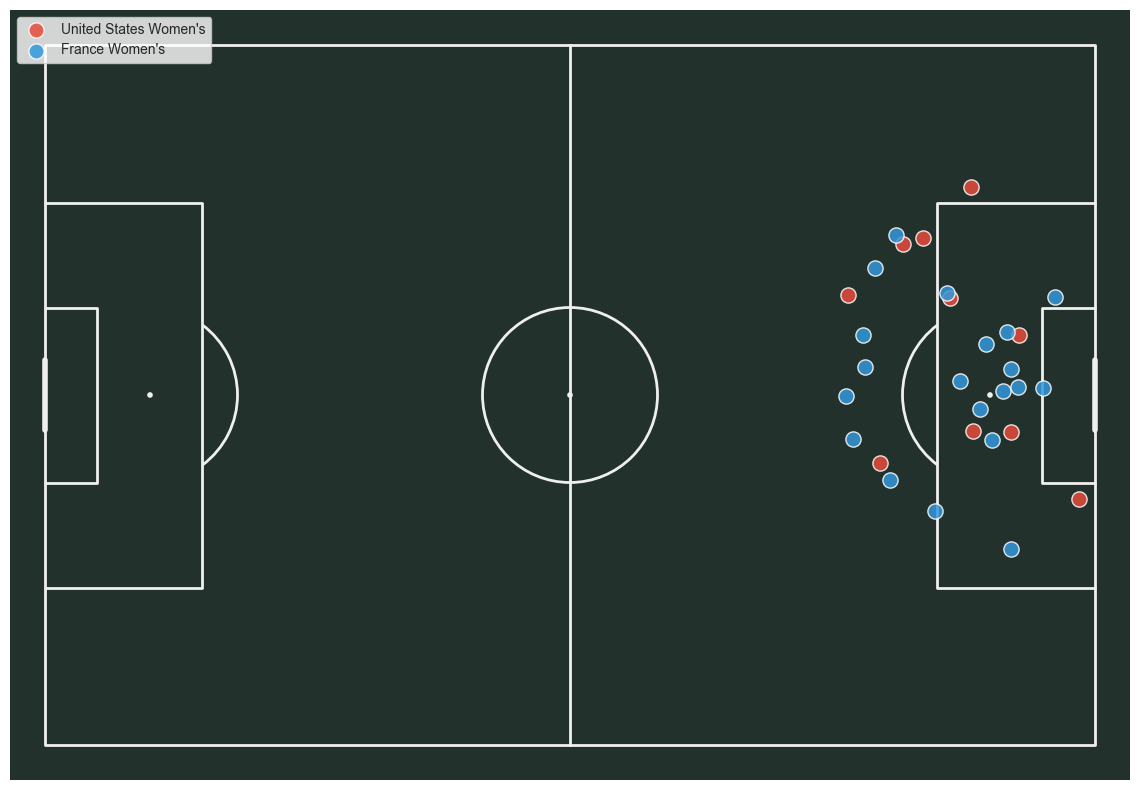

✅ Shot map saved. Shots per team:
team_name
France Women's           20
United States Women's    10
dtype: int64


In [14]:
# ▶️ CATCH-UP CELL — run this if your shot map didn't come out.
pitch = Pitch(pitch_color="#22312b", line_color="#efefef", linewidth=2)
fig, ax = pitch.draw(figsize=(12, 8))
teams = shots["team_name"].unique()
colors = ["#e74c3c", "#3498db"]
for team, color in zip(teams, colors):
    tshots = shots[shots["team_name"] == team]
    ax.scatter(tshots["x"], tshots["y"], s=120, c=color, edgecolors="white",
               label=team, alpha=0.85, zorder=3)
ax.legend(loc="upper left")
plt.savefig("my_shot_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Shot map saved. Shots per team:")
print(shots.groupby("team_name").size())


### Bonus: Passing Network (Instructor Demo)

A passing network shows the tactical structure of a team: who passes to whom,
and where players position themselves on average. Nodes = players, edges = pass
frequency, node size = involvement.

This is a **demo only** — the code is here for you to explore later\!

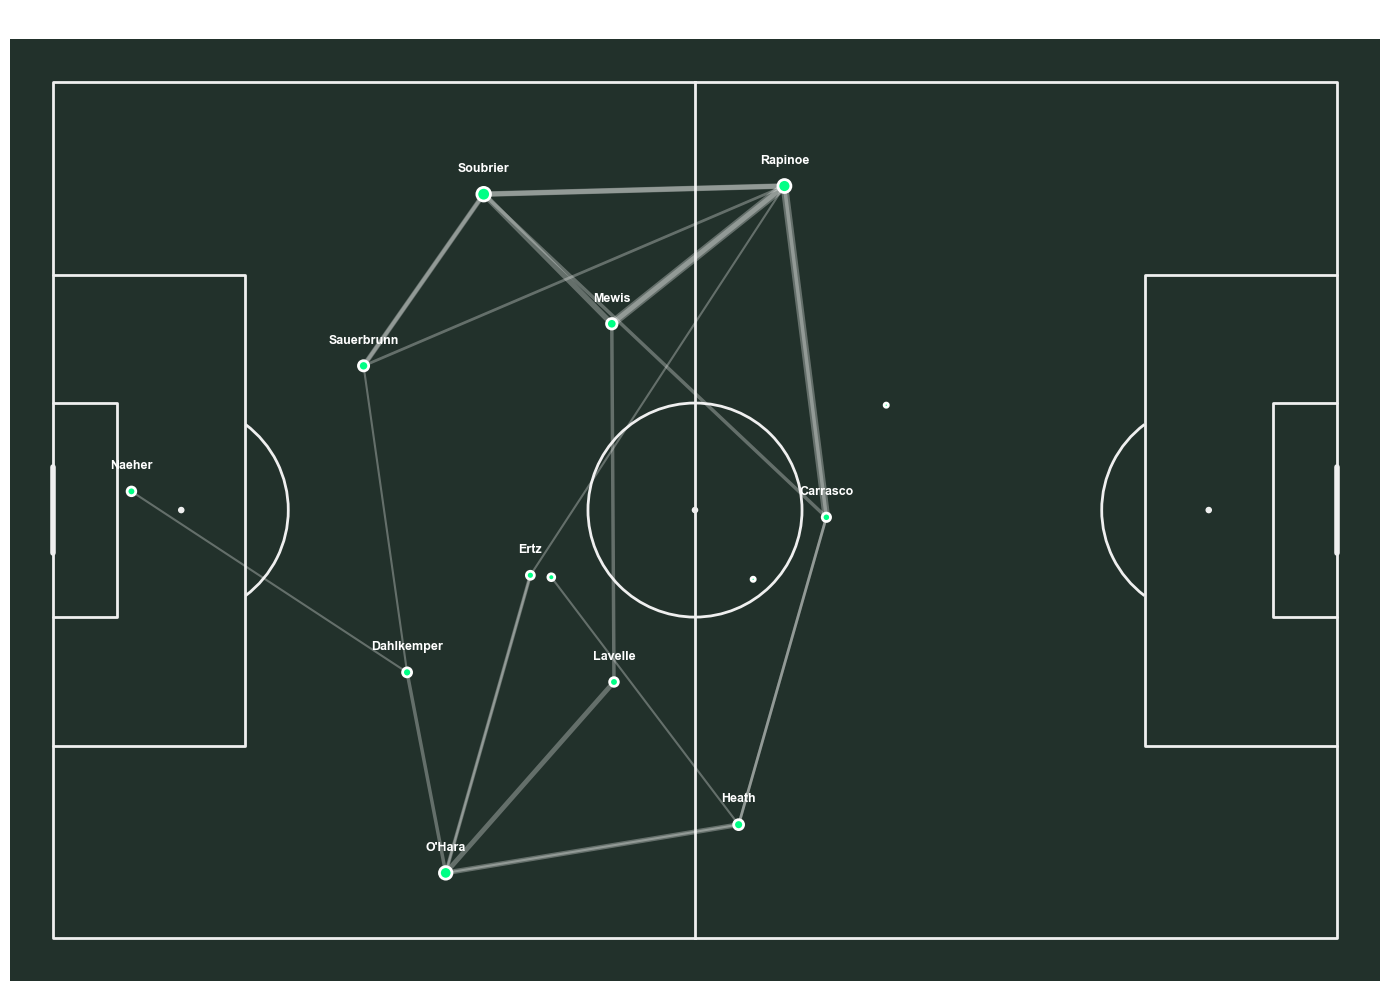

In [15]:
# === Instructor Demo: Passing Network ===
team_name = teams[0]

# Completed passes
passes = events_df.query(
    "type_name == 'Pass' and team_name == @team_name"
).copy()
passes["completed"] = passes["pass_outcome_name"].isna()
passes = passes[passes["completed"]]

# Extract passer and receiver
passes["passer"] = passes["player_name"]
if "pass_recipient_name" in passes.columns:
    passes["receiver"] = passes["pass_recipient_name"]
else:
    passes["receiver"] = None

# Extract coordinates
if "location" in passes.columns:
    passes[["x", "y"]] = passes["location"].apply(pd.Series)
elif "location_0" in passes.columns:
    passes["x"] = passes["location_0"]
    passes["y"] = passes["location_1"]

passes = passes.dropna(subset=["passer", "receiver", "x", "y"])

# Average positions
player_pos = passes.groupby("passer").agg(
    avg_x=("x", "mean"), avg_y=("y", "mean"), num_passes=("passer", "count")
).reset_index()

# Pass pairs (min 3 passes)
pass_between = passes.groupby(["passer", "receiver"]).size().reset_index(name="pass_count")
pass_between = pass_between[pass_between["pass_count"] >= 3]

# Draw
pitch = Pitch(pitch_color="#22312b", line_color="#efefef", linewidth=2)
fig, ax = pitch.draw(figsize=(14, 10))

for _, row in pass_between.iterrows():
    p1 = player_pos[player_pos["passer"] == row["passer"]]
    p2 = player_pos[player_pos["passer"] == row["receiver"]]
    if len(p1) > 0 and len(p2) > 0:
        pitch.lines(
            p1.iloc[0]["avg_x"], p1.iloc[0]["avg_y"],
            p2.iloc[0]["avg_x"], p2.iloc[0]["avg_y"],
            ax=ax, color="white", alpha=0.3, lw=row["pass_count"] / 2, zorder=1
        )

pitch.scatter(
    player_pos["avg_x"], player_pos["avg_y"],
    s=player_pos["num_passes"] * 3, color="#00ff85",
    edgecolors="white", linewidth=2, ax=ax, zorder=3
)

for _, p in player_pos.nlargest(11, "num_passes").iterrows():
    name = p["passer"].split()[-1]
    ax.text(p["avg_x"], p["avg_y"] - 3, name,
            ha="center", va="top", fontsize=9, color="white", weight="bold")

ax.set_title(f"Passing Network: {team_name}", fontsize=16, color="white", pad=10)
plt.tight_layout()
plt.show()

---
## Part 3: Feature Engineering for xG (Exercise 3)

Expected Goals (xG) estimates the **probability** that a shot will result in a goal.
This is a **binary classification** problem — the same type of model used for
medical diagnosis, fraud detection, and customer churn prediction.

Two key features for xG:
- **Distance from the goal** — closer shots are more likely to score
- **Angle to the goal** — wider angles give more of the goal to aim at

**Book reference:** Chapter 5 — *Predicting Soccer Outcomes with Classification*

### ✏️ Exercise 3: Engineer distance and angle features

**Task:** For every shot, calculate:
1. `distance_to_goal` — Euclidean distance from shot to goal center (x=120, y=40)
2. `angle_to_goal` — Angle subtended by the goal posts (goal width = 7.32m)

**Formulas:**
- Distance: `sqrt((120 - x)^2 + (40 - y)^2)`
- Angle: `arctan(7.32 * (120 - x) / ((120 - x)^2 + (40 - y)^2 - 3.66^2))`

**Output:** Paste the distance and angle values for the first goal into the chat.

**Time:** 8 minutes

In [ ]:
# === YOUR CODE HERE ===

GOAL_X, GOAL_Y = 120, 40
GOAL_WIDTH = 7.32

# Step 1: Calculate distance to goal
# Hint: np.sqrt((GOAL_X - shots["x"])**2 + (GOAL_Y - shots["y"])**2)
shots["distance_to_goal"] = ____

# Step 2: Calculate angle to goal
# Hint: np.degrees(np.arctan(GOAL_WIDTH * (GOAL_X - shots["x"]) /
#       ((GOAL_X - shots["x"])**2 + (GOAL_Y - shots["y"])**2 - (GOAL_WIDTH/2)**2)))
shots["angle_to_goal"] = ____

# Inspect
print("Engineered features:")
print(shots[["player_name", "team_name", "x", "y",
             "distance_to_goal", "angle_to_goal", "is_goal"]].head(10))

# First goal
first_goal = shots[shots["is_goal"] == 1].iloc[0]
print(f"\n--- First goal ---")
print(f"Player: {first_goal['player_name']}")
print(f"Distance: {first_goal['distance_to_goal']:.1f} meters")
print(f"Angle: {first_goal['angle_to_goal']:.1f} degrees")

In [16]:
# ▶️ CATCH-UP CELL — run this if your features didn't compute.
GOAL_X, GOAL_Y, GOAL_WIDTH = 120, 40, 7.32
shots["distance_to_goal"] = np.sqrt((GOAL_X - shots["x"])**2 + (GOAL_Y - shots["y"])**2)
shots["angle_to_goal"] = np.degrees(np.arctan(
    GOAL_WIDTH * (GOAL_X - shots["x"]) /
    ((GOAL_X - shots["x"])**2 + (GOAL_Y - shots["y"])**2 - (GOAL_WIDTH / 2)**2)
))
print("✅ Features ready:")
print(shots[["player_name", "team_name", "distance_to_goal", "angle_to_goal", "is_goal"]].head())


✅ Features ready:
                   player_name              team_name  distance_to_goal  \
50             Julie Beth Ertz  United States Women's         25.806976   
131         Megan Anna Rapinoe  United States Women's         27.714256   
351          Eugénie Le Sommer         France Women's         12.854960   
372  Alexandra Morgan Carrasco  United States Women's         19.969226   
465             Valérie Gauvin         France Women's         20.554805   

     angle_to_goal  is_goal  
50       15.425686        0  
131       7.842108        1  
351      29.631566        0  
372      17.500530        0  
465      16.824653        0  


<details>
<summary>💡 Click for solution</summary>

```python
shots["distance_to_goal"] = np.sqrt(
    (GOAL_X - shots["x"])**2 + (GOAL_Y - shots["y"])**2
)

shots["angle_to_goal"] = np.degrees(np.arctan(
    GOAL_WIDTH * (GOAL_X - shots["x"]) /
    ((GOAL_X - shots["x"])**2 + (GOAL_Y - shots["y"])**2 - (GOAL_WIDTH / 2)**2)
))
```
</details>

---
## Part 4: Training the xG Model (Exercise 4)

Now we train a **logistic regression** — the algorithm behind xG.
It uses the sigmoid function to map features to a probability between 0 and 1.

**Note:** With one match of shots, our model is simple. A production xG model
trains on thousands of shots. But the *method* is identical.

### ✏️ Exercise 4: Train a logistic regression xG model

**Steps:**
1. Select features and split data (80/20)
2. Train `LogisticRegression`
3. Check accuracy

**Output:** Paste your accuracy score into the chat.

**Time:** 8 minutes

In [ ]:
# === YOUR CODE HERE ===

features = ["distance_to_goal", "angle_to_goal"]
X = shots[features].dropna()
y = shots.loc[X.index, "is_goal"]

# Split (fill in test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=____, random_state=42
)

# Train
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy:.3f}")
print(f"\nCoefficients:")
for feature, coef in zip(features, model.coef_[0]):
    direction = "decreases" if coef < 0 else "increases"
    print(f"  {feature}: {coef:.4f} ({direction} goal probability)")

In [17]:
# ▶️ CATCH-UP CELL — run this if your model didn't train.
features = ["distance_to_goal", "angle_to_goal"]
X = shots[features].dropna()
y = shots.loc[X.index, "is_goal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression().fit(X_train, y_train)
print(f"✅ Model trained. Accuracy: {accuracy_score(y_test, model.predict(X_test)):.3f}")


✅ Model trained. Accuracy: 1.000


<details>
<summary>💡 Click for solution</summary>

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```
</details>

In [18]:
# === Apply xG back to the match ===
shots["xG"] = model.predict_proba(shots[features].dropna())[:, 1]

xg_summary = shots.groupby("team_name").agg(
    shots=("is_goal", "count"),
    goals=("is_goal", "sum"),
    total_xG=("xG", "sum")
).round(2)

print("\n=== Match xG Summary ===")
print(xg_summary)
print(f"\nDid xG agree with the actual result?")


=== Match xG Summary ===
                       shots  goals  total_xG
team_name                                    
France Women's            20      1      2.88
United States Women's     10      2      0.88

Did xG agree with the actual result?


---
## Part 4b: The Market as a Benchmark (Bonus)

Your xG model is one opinion on the match. The **betting market** is another — a
crowd-sourced forecast priced into the odds. Comparing the two is a great sanity check,
and it's the gateway to **Chapter 9 (Betting Analytics)**.

Three quick ideas:
1. **Decimal odds → implied probability:** `implied = 1 / odds`.
2. **The overround:** raw implied probabilities sum to *more* than 100% — that gap is
   the bookmaker's margin. We "de-vig" by normalising so they sum to 1.
3. **Model vs. market:** does your xG agree with where the market set the favourite?

> The odds below are **illustrative, for teaching the method** — not betting advice.


In [19]:
# Illustrative pre-match 3-way odds for USA vs France (decimal format).
# In practice you'd pull these from an odds feed; here they're fixed for the lesson.
odds = {"USA win": 1.65, "Draw": 3.90, "France win": 4.80}

# Step 1 — raw implied probability from each price
implied = {k: 1 / v for k, v in odds.items()}
overround = sum(implied.values())
print(f"Raw implied probabilities sum to {overround:.3f}  (the {(overround-1)*100:.1f}% above 100% is the bookmaker margin)\n")

# Step 2 — de-vig: normalise so probabilities sum to 1
fair = {k: p / overround for k, p in implied.items()}
for k in odds:
    print(f"{k:11s}  odds {odds[k]:.2f}  ->  implied {implied[k]*100:4.1f}%  ->  fair {fair[k]*100:4.1f}%")

# Step 3 — compare the market's favourite to your model
market_usa = fair["USA win"]
print(f"\nThe market gave USA roughly {market_usa*100:.0f}% to win in 90 minutes.")
print("Compare that to your xG totals above: does the model agree on who was on top?")
print("That comparison — model vs. market — is exactly what Chapter 9 builds on.")


Raw implied probabilities sum to 1.071  (the 7.1% above 100% is the bookmaker margin)

USA win      odds 1.65  ->  implied 60.6%  ->  fair 56.6%
Draw         odds 3.90  ->  implied 25.6%  ->  fair 23.9%
France win   odds 4.80  ->  implied 20.8%  ->  fair 19.5%

The market gave USA roughly 57% to win in 90 minutes.
Compare that to your xG totals above: does the model agree on who was on top?
That comparison — model vs. market — is exactly what Chapter 9 builds on.


---
## Part 5: Poisson Regression for Goal Counts (Exercise 5)

xG tells us about individual shots. But what about predicting **how many goals**
a team scores? Goals are **count data** (0, 1, 2, 3...). Regular linear regression
could predict -0.3 goals — nonsensical. **Poisson regression** is designed for counts.

The same model is used in insurance (claims), healthcare (admissions),
and web analytics (visits per session).

**Book reference:** Chapter 4 — *Counting Goals: Poisson Regression*

In [20]:
# Build a dataset from all available matches
all_match_ids = matches_df["match_id"].tolist()
all_events = []

for mid in all_match_ids:
    fpath = DATA_DIR / f"events_{mid}.json"
    if fpath.exists():
        raw = json.load(open(fpath, "r"))
        df = pd.json_normalize(raw, sep="_")
        df["match_id"] = mid
        all_events.append(df)

if len(all_events) > 1:
    all_events_df = pd.concat(all_events, ignore_index=True)
    print(f"Loaded events from {len(all_events)} matches")
else:
    all_events_df = events_df.copy()
    print("Using single match data (limited, but the method is the same)")

Loaded events from 52 matches


In [21]:
# Build per-team-per-match summary
all_shots_df = all_events_df[all_events_df["type_name"] == "Shot"].copy()
all_shots_df["is_goal"] = (all_shots_df["shot_outcome_name"] == "Goal").astype(int)

team_match_stats = all_shots_df.groupby(["match_id", "team_name"]).agg(
    goals=("is_goal", "sum"),
    shots=("is_goal", "count")
).reset_index()

# Shots on target
sot = all_shots_df[all_shots_df["shot_outcome_name"].isin(["Goal", "Saved"])]
sot_counts = sot.groupby(["match_id", "team_name"]).size().reset_index(name="shots_on_target")
team_match_stats = team_match_stats.merge(sot_counts, on=["match_id", "team_name"], how="left")
team_match_stats["shots_on_target"] = team_match_stats["shots_on_target"].fillna(0)

print(f"Team-match summary: {len(team_match_stats)} rows")
team_match_stats.head(10)

Team-match summary: 104 rows


,match_id,team_name,goals,shots,shots_on_target
0,22921,France Women's,4,21,8.0
1,22921,Korea Republic Women's,0,5,0.0
2,22924,Nigeria Women's,0,10,1.0
3,22924,Norway Women's,2,10,4.0
4,22926,China PR Women's,0,5,1.0
5,22926,Germany Women's,1,16,4.0
6,22930,South Africa Women's,1,4,2.0
7,22930,Spain Women's,3,28,11.0
8,22933,Australia Women's,1,16,5.0
9,22933,Italy Women's,2,6,3.0


### ✏️ Exercise 5: Build a Poisson regression model

**Task:** Fit a Poisson GLM predicting goals from shots on target.

**Output:** Paste predicted goals for each team in our match into the chat.

**Time:** 10 minutes

In [22]:
# === YOUR CODE HERE ===

y_poisson = team_match_stats["goals"]
X_poisson = sm.add_constant(team_match_stats[["shots_on_target"]])

# Fit the Poisson GLM
poisson_model = sm.GLM(
    y_poisson, X_poisson,
    family=sm.families.Poisson()  # The key: Poisson family for count data
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                  104
Model:                            GLM   Df Residuals:                      102
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -131.07
Date:                Thu, 02 Jul 2026   Deviance:                       90.202
Time:                        11:06:39   Pearson chi2:                     72.9
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5751
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.5890      0.137     

In [23]:
# Predict for our match
our_match = team_match_stats[team_match_stats["match_id"] == MATCH_ID]

if len(our_match) > 0:
    X_pred = sm.add_constant(our_match[["shots_on_target"]])
    predicted = poisson_model.predict(X_pred)

    print("\n=== Poisson Predictions for Our Match ===")
    for i, (_, row) in enumerate(our_match.iterrows()):
        print(f"{row['team_name']}: {predicted.iloc[i]:.2f} predicted goals "
              f"(actual: {row['goals']})")
else:
    print("Match not found in dataset.")


=== Poisson Predictions for Our Match ===
France Women's: 1.28 predicted goals (actual: 1)
United States Women's: 2.12 predicted goals (actual: 2)


---
## Part 6: Neural Network Overview (Bonus — Instructor Demo)

A **neural network** is a logistic regression with extra layers that learn feature
combinations automatically. Same idea, more parameters, more flexibility.

This is a **walkthrough only** — no exercise. The code is here for after the course.

**Book reference:** Chapter 7 — *Deep Learning for Soccer Analytics*

In [24]:
# === Instructor Demo: Neural Network Architecture ===
try:
    import torch
    import torch.nn as nn

    class SoccerNet(nn.Module):
        def __init__(self, input_size):
            super().__init__()
            self.fc1 = nn.Linear(input_size, 16)   # Hidden layer
            self.relu = nn.ReLU()                    # Activation
            self.fc2 = nn.Linear(16, 1)              # Output
            self.sigmoid = nn.Sigmoid()              # Probability

        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.sigmoid(self.fc2(x))
            return x

    model_nn = SoccerNet(input_size=2)
    print("Neural Network Architecture:")
    print(model_nn)
    n_params = sum(p.numel() for p in model_nn.parameters())
    print(f"\nTotal parameters: {n_params}")
    print("Compare: logistic regression had 3 parameters.")
    print(f"This network has {n_params} -- more flexible, but more prone to overfitting.")

except ImportError:
    print("PyTorch not installed. That is fine -- this is a walkthrough only.")
    print("\nKey takeaway: a neural network is logistic regression with extra layers")
    print("that automatically learn feature combinations.")
    print("\nSee Chapter 7 of the book for the full implementation.")

Neural Network Architecture:
SoccerNet(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parameters: 65
Compare: logistic regression had 3 parameters.
This network has 65 -- more flexible, but more prone to overfitting.


---
## Summary: One Match, Many Lenses

Today we took a single World Cup match and analyzed it through progressively
sophisticated models:

| Technique | Question | Model type |
|-----------|----------|------------|
| **Shot map** | Where did teams shoot from? | Visualization |
| **Passing network** | How did the team structure its play? | Network analysis |
| **xG (Logistic Regression)** | What was each shot worth? | Binary classification |
| **Poisson Regression** | How many goals should we expect? | Count regression |
| **Neural Network** | Can we learn richer patterns? | Deep learning |

### These techniques generalize far beyond soccer:

| Soccer application | General application |
|-------------------|---------------------|
| xG (goal or no goal?) | Medical diagnosis, fraud detection, churn prediction |
| Poisson (goal counts) | Insurance claims, hospital admissions, web traffic |
| Neural networks | Image recognition, NLP, recommendation systems |
| Feature engineering | Domain expertise to model input, in any field |

### Your next steps:
- Read the companion book on the O'Reilly platform
- Explore the GitHub repo notebooks for every chapter
- Use `statsbombpy` to load any match from the open data
- Watch tonight's World Cup match with new eyes\!

---

**Thank you for joining us\!**

Book: *Soccer Analytics with Machine Learning* (O'Reilly, 2026)  
Code: [github.com/SoccerAnalyticsML](https://github.com/SoccerAnalyticsML/Soccer-Analytics-with-Machine-Learning)  
Data: [github.com/statsbomb/open-data](https://github.com/statsbomb/open-data)